In [1]:
import pandas as pd
import os

In [10]:
df = pd.read_csv('../data/data_variable_edit.csv')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Sample     180 non-null    str    
 1   DV1 BR90   180 non-null    float64
 2   DV2 265    180 non-null    float64
 3   DV3 98     180 non-null    float64
 4   DV4 360    180 non-null    float64
 5   Cells      180 non-null    str    
 6   Treatment  180 non-null    str    
dtypes: float64(4), str(3)
memory usage: 10.0 KB


In [11]:
df.describe()

,DV1 BR90,DV2 265,DV3 98,DV4 360
count,180.000000,180.000000,180.000000,180.000000
mean,7.263833,7.413167,9.108333,6.624167
std,10.454712,10.944008,13.001236,10.534487
min,0.110000,0.110000,0.080000,0.010000
25%,1.387500,1.357500,1.067500,0.835000
50%,2.790000,2.595000,3.390000,1.970000
75%,6.900000,7.765000,12.047500,6.150000
max,52.380000,53.190000,81.420000,50.880000


In [14]:
df.select_dtypes(include='object').describe()

/tmp/ipykernel_10408/2255937484.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').describe()


,Sample,Cells,Treatment
count,180,180,180
unique,6,6,5
top,Sample 1,CD4/CD8/CD19,Untreated
freq,30,30,36


In [15]:
len(df[df['Sample'] == 'Sample 1'])

30

In [19]:
df.query('Cells == "CD4/CD8/CD19" and Sample == "Sample 1"')[['Cells', 'Sample']]

,Cells,Sample
0,CD4/CD8/CD19,Sample 1
36,CD4/CD8/CD19,Sample 1
72,CD4/CD8/CD19,Sample 1
108,CD4/CD8/CD19,Sample 1
144,CD4/CD8/CD19,Sample 1


In [20]:
df.loc[:, ['Cells', 'Sample']]

,Cells,Sample
0,CD4/CD8/CD19,Sample 1
1,CD4/CD8/CD19,Sample 2
2,CD4/CD8/CD19,Sample 3
3,CD4/CD8/CD19,Sample 4
4,CD4/CD8/CD19,Sample 5
...,...,...
175,CD8,Sample 2
176,CD8,Sample 3
177,CD8,Sample 4
178,CD8,Sample 5


In [21]:
df.loc[::-1]

,Sample,DV1 BR90,DV2 265,DV3 98,DV4 360,Cells,Treatment
179,Sample 6,0.65,0.65,0.65,0.65,CD8,Mock
178,Sample 5,0.60,0.60,0.60,0.60,CD8,Mock
177,Sample 4,0.76,0.76,0.76,0.76,CD8,Mock
176,Sample 3,0.58,0.58,0.58,0.58,CD8,Mock
175,Sample 2,0.45,0.45,0.45,0.45,CD8,Mock
...,...,...,...,...,...,...,...
4,Sample 5,49.51,51.85,51.10,47.40,CD4/CD8/CD19,Untreated
3,Sample 4,52.38,52.49,58.69,38.85,CD4/CD8/CD19,Untreated
2,Sample 3,45.37,52.28,42.48,50.88,CD4/CD8/CD19,Untreated
1,Sample 2,52.17,52.71,52.13,49.19,CD4/CD8/CD19,Untreated


In [26]:
df[df.columns[1:5]].head()

,DV1 BR90,DV2 265,DV3 98,DV4 360
0,44.54,39.56,81.42,48.23
1,52.17,52.71,52.13,49.19
2,45.37,52.28,42.48,50.88
3,52.38,52.49,58.69,38.85
4,49.51,51.85,51.10,47.40


In [28]:
df[df[df.columns[-2]].isin(['CD4'])].head()

,Sample,DV1 BR90,DV2 265,DV3 98,DV4 360,Cells,Treatment
24,Sample 1,6.65,3.24,9.12,7.16,CD4,Untreated
25,Sample 2,6.40,5.83,8.08,6.14,CD4,Untreated
26,Sample 3,6.15,8.41,7.03,5.12,CD4,Untreated
27,Sample 4,6.40,5.83,8.08,6.14,CD4,Untreated
28,Sample 5,6.32,6.69,7.73,5.80,CD4,Untreated


In [29]:
df.value_counts('Cells')

Cells
CD4/CD8/CD19    30
CD4/CD8         30
CD14            30
CD19            30
CD4             30
CD8             30
Name: count, dtype: int64

In [30]:
df.sort_index()

,Sample,DV1 BR90,DV2 265,DV3 98,DV4 360,Cells,Treatment
0,Sample 1,44.54,39.56,81.42,48.23,CD4/CD8/CD19,Untreated
1,Sample 2,52.17,52.71,52.13,49.19,CD4/CD8/CD19,Untreated
2,Sample 3,45.37,52.28,42.48,50.88,CD4/CD8/CD19,Untreated
3,Sample 4,52.38,52.49,58.69,38.85,CD4/CD8/CD19,Untreated
4,Sample 5,49.51,51.85,51.10,47.40,CD4/CD8/CD19,Untreated
...,...,...,...,...,...,...,...
175,Sample 2,0.45,0.45,0.45,0.45,CD8,Mock
176,Sample 3,0.58,0.58,0.58,0.58,CD8,Mock
177,Sample 4,0.76,0.76,0.76,0.76,CD8,Mock
178,Sample 5,0.60,0.60,0.60,0.60,CD8,Mock


In [32]:
df.sort_values(by='Cells').value_counts('Cells')

Cells
CD14            30
CD19            30
CD4             30
CD4/CD8         30
CD4/CD8/CD19    30
CD8             30
Name: count, dtype: int64

In [33]:
df['DV1 BR90'].nlargest()

3    52.38
1    52.17
5    50.16
4    49.51
2    45.37
Name: DV1 BR90, dtype: float64

In [35]:
df[df.columns].nlargest(5, columns=df.columns[1])

,Sample,DV1 BR90,DV2 265,DV3 98,DV4 360,Cells,Treatment
3,Sample 4,52.38,52.49,58.69,38.85,CD4/CD8/CD19,Untreated
1,Sample 2,52.17,52.71,52.13,49.19,CD4/CD8/CD19,Untreated
5,Sample 6,50.16,53.19,50.76,46.78,CD4/CD8/CD19,Untreated
4,Sample 5,49.51,51.85,51.10,47.40,CD4/CD8/CD19,Untreated
2,Sample 3,45.37,52.28,42.48,50.88,CD4/CD8/CD19,Untreated


In [37]:
pd.get_dummies(df['Treatment'])

,10 ug,20 ug,5 ug,Mock,Untreated
0,False,False,False,False,True
1,False,False,False,False,True
2,False,False,False,False,True
3,False,False,False,False,True
4,False,False,False,False,True
...,...,...,...,...,...
175,False,False,False,True,False
176,False,False,False,True,False
177,False,False,False,True,False
178,False,False,False,True,False


In [40]:
df.value_counts().to_frame().head()

,,,,,,,count
Sample,DV1 BR90,DV2 265,DV3 98,DV4 360,Cells,Treatment,
Sample 1,44.54,39.56,81.42,48.23,CD4/CD8/CD19,Untreated,1
Sample 2,52.17,52.71,52.13,49.19,CD4/CD8/CD19,Untreated,1
Sample 3,45.37,52.28,42.48,50.88,CD4/CD8/CD19,Untreated,1
Sample 4,52.38,52.49,58.69,38.85,CD4/CD8/CD19,Untreated,1
Sample 5,49.51,51.85,51.10,47.40,CD4/CD8/CD19,Untreated,1


In [50]:
coluna_1 = df.columns[0]
coluna_2 = df.columns[-1]

print(coluna_1, coluna_2)

display(
    df.value_counts([coluna_1, coluna_2])
    .to_frame()
    .rename(columns={'count': 'Freq'})
    .sort_index()
)

Sample Treatment


Freq
Sample   Treatment      
Sample 1 10 ug         6
         20 ug         6
         5 ug          6
         Mock          6
         Untreated     6
Sample 2 10 ug         6
         20 ug         6
         5 ug          6
         Mock          6
         Untreated     6
Sample 3 10 ug         6
         20 ug         6
         5 ug          6
         Mock          6
         Untreated     6
Sample 4 10 ug         6
         20 ug         6
         5 ug          6
         Mock          6
         Untreated     6
Sample 5 10 ug         6
         20 ug         6
         5 ug          6
         Mock          6
         Untreated     6
Sample 6 10 ug         6
         20 ug         6
         5 ug          6
         Mock          6
         Untreated     6

In [53]:
df.groupby('Cells').sum()

,Sample,DV1 BR90,DV2 265,DV3 98,DV4 360,Treatment
Cells,,,,,,
CD14,Sample 1Sample 2Sample 3Sample 4Sample 5Sample...,64.31,54.24,150.46,64.45,UntreatedUntreatedUntreatedUntreatedUntreatedU...
CD19,Sample 1Sample 2Sample 3Sample 4Sample 5Sample...,192.37,188.63,278.12,160.54,UntreatedUntreatedUntreatedUntreatedUntreatedU...
CD4,Sample 1Sample 2Sample 3Sample 4Sample 5Sample...,76.95,73.17,79.47,58.43,UntreatedUntreatedUntreatedUntreatedUntreatedU...
CD4/CD8,Sample 1Sample 2Sample 3Sample 4Sample 5Sample...,277.77,292.89,300.59,261.84,UntreatedUntreatedUntreatedUntreatedUntreatedU...
CD4/CD8/CD19,Sample 1Sample 2Sample 3Sample 4Sample 5Sample...,480.33,491.61,588.66,430.64,UntreatedUntreatedUntreatedUntreatedUntreatedU...
CD8,Sample 1Sample 2Sample 3Sample 4Sample 5Sample...,215.76,233.83,242.20,216.45,UntreatedUntreatedUntreatedUntreatedUntreatedU...


In [59]:
colunas = [1,2,3,4,5,6]

(
    df.iloc[:, colunas]
    .groupby(['Cells', 'Treatment'])
    .sum()
)

DV1 BR90  DV2 265  DV3 98  DV4 360
Cells        Treatment                                    
CD14         10 ug          8.52     7.26   22.61     9.72
             20 ug          8.50     8.50   15.94     8.50
             5 ug          13.09    10.66   33.06    12.80
             Mock           6.10     4.96    8.50     5.97
             Untreated     28.10    22.86   70.35    27.46
CD19         10 ug         14.95    14.60   59.73    12.94
             20 ug          9.35     9.35   17.40     9.35
             5 ug          31.49    30.85   57.50    25.90
             Mock           7.69     7.54    9.35     6.33
             Untreated    128.89   126.29  134.14   106.02
CD4          10 ug          7.91     7.64    1.59     0.67
             20 ug          9.60     8.74    4.43     1.24
             5 ug          17.64    16.22   22.21    16.88
             Mock           3.59     3.59    3.59     3.59
             Untreated     38.21    36.98   47.65    36.05
CD4/CD8      10 ug         25.58    27.53    2.66     4.52
             20 ug         13.38    12.48    5.93     1.83
             5 ug          73.54    76.90   89.38    78.73
             Mock           7.08     7.16    6.86     7.18
             Untreated    158.19   168.82  195.76   169.58
CD4/CD8/CD19 10 ug         41.27    42.86   62.18    18.04
             20 ug         23.13    22.23   23.58    11.56
             5 ug         106.67   109.38  149.71   105.93
             Mock          15.13    15.06   16.61    13.78
             Untreated    294.13   302.08  336.58   281.33
CD8          10 ug         19.04    21.16    2.53     5.16
             20 ug          4.81     4.77    2.93     1.60
             5 ug          58.50    63.09   72.44    64.10
             Mock           4.30     4.30    4.30     4.30
             Untreated    129.11   140.51  160.00   141.29

In [61]:
colunas = [1,2,3,4,5,6]

(
    df.iloc[:, colunas]
    .groupby(['Cells', 'Treatment'])
    .mean()
    .round()
)

DV1 BR90  DV2 265  DV3 98  DV4 360
Cells        Treatment                                    
CD14         10 ug           1.0      1.0     4.0      2.0
             20 ug           1.0      1.0     3.0      1.0
             5 ug            2.0      2.0     6.0      2.0
             Mock            1.0      1.0     1.0      1.0
             Untreated       5.0      4.0    12.0      5.0
CD19         10 ug           2.0      2.0    10.0      2.0
             20 ug           2.0      2.0     3.0      2.0
             5 ug            5.0      5.0    10.0      4.0
             Mock            1.0      1.0     2.0      1.0
             Untreated      21.0     21.0    22.0     18.0
CD4          10 ug           1.0      1.0     0.0      0.0
             20 ug           2.0      1.0     1.0      0.0
             5 ug            3.0      3.0     4.0      3.0
             Mock            1.0      1.0     1.0      1.0
             Untreated       6.0      6.0     8.0      6.0
CD4/CD8      10 ug           4.0      5.0     0.0      1.0
             20 ug           2.0      2.0     1.0      0.0
             5 ug           12.0     13.0    15.0     13.0
             Mock            1.0      1.0     1.0      1.0
             Untreated      26.0     28.0    33.0     28.0
CD4/CD8/CD19 10 ug           7.0      7.0    10.0      3.0
             20 ug           4.0      4.0     4.0      2.0
             5 ug           18.0     18.0    25.0     18.0
             Mock            3.0      3.0     3.0      2.0
             Untreated      49.0     50.0    56.0     47.0
CD8          10 ug           3.0      4.0     0.0      1.0
             20 ug           1.0      1.0     0.0      0.0
             5 ug           10.0     11.0    12.0     11.0
             Mock            1.0      1.0     1.0      1.0
             Untreated      22.0     23.0    27.0     24.0

In [63]:
pd.crosstab(df['Cells'], df['Treatment'], margins=True)

Treatment,10 ug,20 ug,5 ug,Mock,Untreated,All
Cells,,,,,,
CD14,6,6,6,6,6,30
CD19,6,6,6,6,6,30
CD4,6,6,6,6,6,30
CD4/CD8,6,6,6,6,6,30
CD4/CD8/CD19,6,6,6,6,6,30
CD8,6,6,6,6,6,30
All,36,36,36,36,36,180


In [64]:
df.pivot_table(
    index='Cells',
    columns='Treatment',
    values='DV1 BR90',
    aggfunc='mean'
)

Treatment,10 ug,20 ug,5 ug,Mock,Untreated
Cells,,,,,
CD14,1.420000,1.416667,2.181667,1.016667,4.683333
CD19,2.491667,1.558333,5.248333,1.281667,21.481667
CD4,1.318333,1.600000,2.940000,0.598333,6.368333
CD4/CD8,4.263333,2.230000,12.256667,1.180000,26.365000
CD4/CD8/CD19,6.878333,3.855000,17.778333,2.521667,49.021667
CD8,3.173333,0.801667,9.750000,0.716667,21.518333


In [77]:
(
    df['DV4 360']
    .to_frame()
    .sort_values(by='DV4 360', ascending=False)
    .head(10)
    .style
    .text_gradient(cmap='Blues')
)

,DV4 360
2,50.880000
1,49.190000
0,48.230000
4,47.400000
5,46.780000
3,38.850000
8,29.840000
11,28.910000
10,28.620000
9,28.350000


In [82]:
id_max = df['DV1 BR90'] == df['DV1 BR90'].max()

id_max.head()

0    False
1    False
2    False
3     True
4    False
Name: DV1 BR90, dtype: bool

In [84]:
import seaborn as sns
import matplotlib as plt

AttributeError: module 'matplotlib' has no attribute 'show'

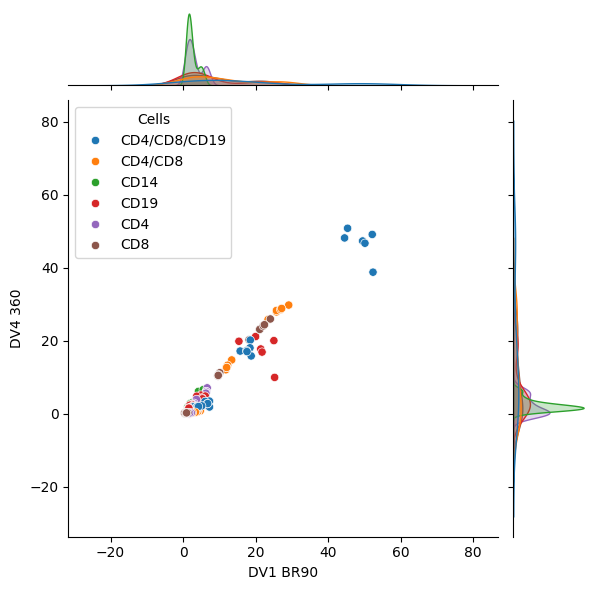

In [95]:
sns.jointplot(
    data=df[df['Treatment'] != "Mock"],
    x='DV1 BR90',
    y='DV4 360',
    #kind='reg',
    hue='Cells',
)

plt.show()

In [100]:
import cowsay

cowsay.kitty("Muito dificil seloko")

  ____________________
| Muito dificil seloko |
                       \
                        \
                         \
                          \
                           ("`-'  '-/") .___..--' ' "`-._
                            ` *_ *  )    `-.   (      ) .`-.__. `)
                             (_Y_.) ' ._   )   `._` ;  `` -. .-'
                          _.. `--'_..-_/   /--' _ .' ,4
                         ( i l ),-''  ( l i),'  ( ( ! .-'
